In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
# !pip install -q torch_geometric
# !pip install -q class_resolver
# !pip3 install pymatting

In [3]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import transforms
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss
from torch.utils.data import TensorDataset, DataLoader, Subset
import random

/home/snu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
data = np.load('/home/snu/Downloads/breastmnist_224.npz', allow_pickle=True)

all_images = np.concatenate([data['train_images'], data['val_images'], data['test_images']], axis=0)
all_labels = np.concatenate([data['train_labels'], data['val_labels'], data['test_labels']], axis=0).squeeze()

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),  # grayscale → 3-channel
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

images = torch.stack([transform(img) for img in all_images])
labels = torch.tensor(all_labels).long()

In [5]:
dataset = TensorDataset(images, labels)
class0_indices = [i for i in range(len(labels)) if labels[i] == 0]
class1_indices = [i for i in range(len(labels)) if labels[i] == 1]

random.seed(42)
sampled_class0 = random.sample(class0_indices, min(1000, len(class0_indices)))
sampled_class1 = random.sample(class1_indices, min(1000, len(class1_indices)))
combined_indices = sampled_class0 + sampled_class1
random.shuffle(combined_indices)
print()
final_dataset = Subset(dataset, combined_indices)
final_loader = DataLoader(final_dataset, batch_size=64, shuffle=False)

print(f"Number of samples in class 0: {len(sampled_class0)}")
print(f"Number of samples in class 1: {len(sampled_class1)}")
device = "cuda" if torch.cuda.is_available() else "cpu"


Number of samples in class 0: 210
Number of samples in class 1: 570


In [6]:
import torchvision.models as models
import torch.nn as nn

resnet = models.resnet18(pretrained=True)
resnet.fc = nn.Identity()  # Remove final classification layer
resnet = resnet.cuda() if torch.cuda.is_available() else resnet
resnet.eval()
resnet_feats = []
y_list = []

with torch.no_grad():
    for imgs, labels in final_loader:
        imgs = imgs.cuda() if torch.cuda.is_available() else imgs
        features = resnet(imgs)
        resnet_feats.append(features.cpu())
        y_list.extend(labels.cpu().tolist())
F = torch.cat(resnet_feats, dim=0).numpy().astype(np.float32)
y_labels = np.array(y_list).astype(np.float32)

print("Feature shape:", F.shape)
print("Label shape:", y_labels.shape)

/home/snu/anaconda3/envs/torch_env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/snu/anaconda3/envs/torch_env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Feature shape: (780, 512)
Label shape: (780,)


In [7]:
kmeans = KMeans(n_clusters=2, random_state=11, max_iter=5000)
kmeans.fit(F)

klabels_trans = kmeans.transform(F)
klabels_trans = klabels_trans / (klabels_trans.sum(axis=1, keepdims=True) + 1e-10)

y_pred = np.argmin(klabels_trans, axis=1)

In [8]:
acc = accuracy_score(y_labels, y_pred)
inv_acc = accuracy_score(y_labels, 1 - y_pred)
if inv_acc > acc:
    acc = inv_acc
    y_pred = 1 - y_pred
    klabels_trans[:, [0, 1]] = klabels_trans[:, [1, 0]]  # swap probs

y_pred_proba = klabels_trans[:, 1]

prec = precision_score(y_labels, y_pred, zero_division=0)
rec = recall_score(y_labels, y_pred, zero_division=0)
f1 = f1_score(y_labels, y_pred, zero_division=0)
logloss = log_loss(y_labels, y_pred_proba)

print("===== KMeans Results (PneumoniaMNIST) =====")
print("Accuracy Score :", acc)
print("Precision Score:", prec)
print("Recall Score   :", rec)
print("F1 Score       :", f1)
print("Log Loss       :", logloss)

===== KMeans Results (PneumoniaMNIST) =====
Accuracy Score : 0.55
Precision Score: 0.6859083191850595
Recall Score   : 0.7087719298245614
F1 Score       : 0.6971527178602244
Log Loss       : 0.7502923454111481


In [9]:
print(y_pred[:20])

[0 0 0 1 1 1 0 1 1 1 1 0 1 0 0 1 1 1 1 1]


In [10]:
print(y_labels[:20])

[1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 0.]


In [11]:
from sklearn.metrics import normalized_mutual_info_score

criterion = nn.CrossEntropyLoss() # Define criterion

num_runs = 10

acc_scores  = []
prec_scores = []
rec_scores  = []
f1_scores   = []
log_losses  = []
ce_losses   = []
nmi_scores  = []

for run in range(num_runs):
    print(f"\n--- Run {run+1}/{num_runs} ---")
    np.random.seed(run)
    torch.manual_seed(run)

    kmeans = KMeans(n_clusters=2, random_state=run, max_iter=5000)
    kmeans.fit(F)

    klabels_trans = kmeans.transform(F)
    klabels_trans = klabels_trans / klabels_trans.sum(axis=1, keepdims=True)

    kS                  = torch.tensor(klabels_trans, dtype=torch.float32).to(device)
    ground_truth_tensor = torch.tensor(y_labels, dtype=torch.long).to(device) # Changed 'y' to 'y_labels'
    ce_loss_value       = criterion(kS, ground_truth_tensor).item()

    y_pred    = torch.argmax(kS, dim=1).cpu().numpy()
    acc_score = accuracy_score(y_labels, y_pred) # Changed 'y' to 'y_labels'

    acc_score_inverted = accuracy_score(y_labels, 1 - y_pred) # Changed 'y' to 'y_labels'
    if acc_score_inverted > acc_score:
        acc_score                = acc_score_inverted
        y_pred                   = 1 - y_pred
        klabels_trans[:, [0, 1]] = klabels_trans[:, [1, 0]]

    y_pred_proba  = klabels_trans[:, 1]

    prec_score    = precision_score(y_labels, y_pred, zero_division=0) # Changed 'y' to 'y_labels'
    rec_score     = recall_score(y_labels, y_pred, zero_division=0) # Changed 'y' to 'y_labels'
    f1            = f1_score(y_labels, y_pred, zero_division=0) # Changed 'y' to 'y_labels'
    log_loss_value = log_loss(y_labels, y_pred_proba) # Changed 'y' to 'y_labels'

    # ── NMI: one value per run, final model only ──
    nmi = normalized_mutual_info_score(y_labels, y_pred, average_method='arithmetic') # Changed 'y' to 'y_labels'

    acc_scores.append(acc_score)
    prec_scores.append(prec_score)
    rec_scores.append(rec_score)
    f1_scores.append(f1)
    log_losses.append(log_loss_value)
    ce_losses.append(ce_loss_value)
    nmi_scores.append(nmi)

    print(f"Run {run+1} | Acc: {acc_score:.4f} | Prec: {prec_score:.4f} | "
          f"Rec: {rec_score:.4f} | F1: {f1:.4f} | NMI: {nmi:.4f} | "
          f"LogLoss: {log_loss_value:.4f} | CE Loss: {ce_loss_value:.4f}")

print("\n================ FINAL SUMMARY ================\n")
print(f"{'Metric':>15} | {'Mean':>10} \u00b1 {'Std':<10}")
print("-" * 50)
print(f"{'Accuracy':>15} | {np.mean(acc_scores):.4f}  \u00b1 {np.std(acc_scores):.4f}")
print(f"{'Precision':>15} | {np.mean(prec_scores):.4f} \u00b1 {np.std(prec_scores):.4f}")
print(f"{'Recall':>15} | {np.mean(rec_scores):.4f}  \u00b1 {np.std(rec_scores):.4f}")
print(f"{'F1 Score':>15} | {np.mean(f1_scores):.4f}  \u00b1 {np.std(f1_scores):.4f}")
print(f"{'NMI':>15} | {np.mean(nmi_scores):.4f}  \u00b1 {np.std(nmi_scores):.4f}")
print(f"{'Log Loss':>15} | {np.mean(log_losses):.4f}  \u00b1 {np.std(log_losses):.4f}")
print(f"{'CE Loss':>15} | {np.mean(ce_losses):.4f}  \u00b1 {np.std(ce_losses):.4f}")


--- Run 1/10 ---
Run 1 | Acc: 0.5359 | Prec: 0.6818 | Rec: 0.6842 | F1: 0.6830 | NMI: 0.0317 | LogLoss: 0.6708 | CE Loss: 0.6785

--- Run 2/10 ---
Run 2 | Acc: 0.5500 | Prec: 0.6859 | Rec: 0.7088 | F1: 0.6972 | NMI: 0.0308 | LogLoss: 0.6692 | CE Loss: 0.6774

--- Run 3/10 ---
Run 3 | Acc: 0.5359 | Prec: 0.6818 | Rec: 0.6842 | F1: 0.6830 | NMI: 0.0317 | LogLoss: 0.6708 | CE Loss: 0.7153

--- Run 4/10 ---
Run 4 | Acc: 0.5359 | Prec: 0.6818 | Rec: 0.6842 | F1: 0.6830 | NMI: 0.0317 | LogLoss: 0.6708 | CE Loss: 0.7153

--- Run 5/10 ---
Run 5 | Acc: 0.5359 | Prec: 0.6818 | Rec: 0.6842 | F1: 0.6830 | NMI: 0.0317 | LogLoss: 0.6708 | CE Loss: 0.6785

--- Run 6/10 ---
Run 6 | Acc: 0.5500 | Prec: 0.6859 | Rec: 0.7088 | F1: 0.6972 | NMI: 0.0308 | LogLoss: 0.6692 | CE Loss: 0.6774

--- Run 7/10 ---
Run 7 | Acc: 0.5359 | Prec: 0.6818 | Rec: 0.6842 | F1: 0.6830 | NMI: 0.0317 | LogLoss: 0.6708 | CE Loss: 0.7153

--- Run 8/10 ---
Run 8 | Acc: 0.5359 | Prec: 0.6933 | Rec: 0.6544 | F1: 0.6733 | NMI: 0.0

==== Running KMeans on PCA (2D) Features Across Multiple Runs ====

--- Run 1/10 ---
Run 1 | Acc: 0.5513 | Prec: 0.6884 | Rec: 0.7053 | F1: 0.6967 | NMI: 0.0260 | LogLoss: 0.7390
--- Run 2/10 ---
Run 2 | Acc: 0.5513 | Prec: 0.6884 | Rec: 0.7053 | F1: 0.6967 | NMI: 0.0260 | LogLoss: 0.7390
--- Run 3/10 ---
Run 3 | Acc: 0.5513 | Prec: 0.6884 | Rec: 0.7053 | F1: 0.6967 | NMI: 0.0260 | LogLoss: 0.7390
--- Run 4/10 ---
Run 4 | Acc: 0.5513 | Prec: 0.6884 | Rec: 0.7053 | F1: 0.6967 | NMI: 0.0260 | LogLoss: 0.7390
--- Run 5/10 ---
Run 5 | Acc: 0.5513 | Prec: 0.6884 | Rec: 0.7053 | F1: 0.6967 | NMI: 0.0260 | LogLoss: 0.7390
--- Run 6/10 ---
Run 6 | Acc: 0.5513 | Prec: 0.6884 | Rec: 0.7053 | F1: 0.6967 | NMI: 0.0260 | LogLoss: 0.7390
--- Run 7/10 ---
Run 7 | Acc: 0.5513 | Prec: 0.6884 | Rec: 0.7053 | F1: 0.6967 | NMI: 0.0260 | LogLoss: 0.7390
--- Run 8/10 ---
Run 8 | Acc: 0.5513 | Prec: 0.6884 | Rec: 0.7053 | F1: 0.6967 | NMI: 0.0260 | LogLoss: 0.7390
--- Run 9/10 ---
Run 9 | Acc: 0.5513 | Prec:

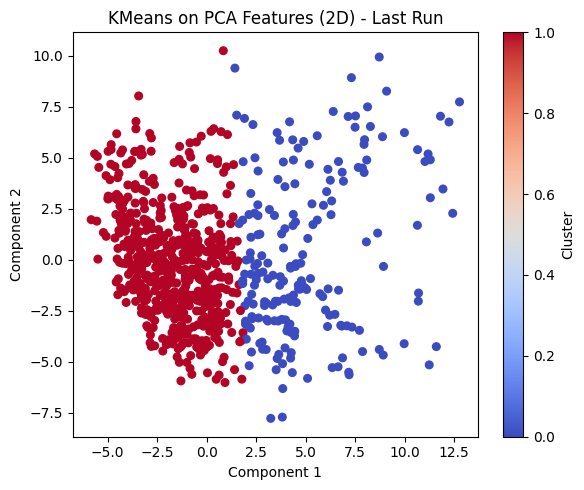

In [14]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, log_loss, normalized_mutual_info_score
)

# -------- PCA on INPUT FEATURES --------
pca = PCA(n_components=2)
Z   = pca.fit_transform(F)   # Z is now (N, 2)

num_runs = 10

acc_scores  = []
prec_scores = []
rec_scores  = []
f1_scores   = []
log_losses  = []
nmi_scores  = []

print("==== Running KMeans on PCA (2D) Features Across Multiple Runs ====\n")

for run in range(num_runs):
    print(f"--- Run {run+1}/{num_runs} ---")
    np.random.seed(run)

    # -------- KMEANS ON 2D PCA FEATURES --------
    kmeans_pca = KMeans(n_clusters=2, random_state=run, max_iter=1000, n_init=10)
    kmeans_pca.fit(Z)

    probs_pca = kmeans_pca.transform(Z)
    probs_pca = probs_pca / probs_pca.sum(axis=1, keepdims=True)

    y_pred_pca = np.argmax(probs_pca, axis=1)

    # Fix label flip
    acc     = accuracy_score(y_labels, y_pred_pca)
    acc_inv = accuracy_score(y_labels, 1 - y_pred_pca)
    if acc_inv > acc:
        y_pred_pca          = 1 - y_pred_pca
        probs_pca[:, [0,1]] = probs_pca[:, [1,0]]
        acc                 = acc_inv

    prec = precision_score(y_labels, y_pred_pca, zero_division=0)
    rec  = recall_score(y_labels, y_pred_pca,    zero_division=0)
    f1   = f1_score(y_labels, y_pred_pca,        zero_division=0)
    ll   = log_loss(y_labels, probs_pca[:, 1])
    nmi  = normalized_mutual_info_score(y_labels, y_pred_pca, average_method='arithmetic')

    acc_scores.append(acc)
    prec_scores.append(prec)
    rec_scores.append(rec)
    f1_scores.append(f1)
    log_losses.append(ll)
    nmi_scores.append(nmi)

    print(f"Run {run+1} | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f} | NMI: {nmi:.4f} | LogLoss: {ll:.4f}")

print("\n================ FINAL SUMMARY (KMeans on PCA 2D) ================\n")
print(f"{'Metric':>15} | {'Mean':>10} \u00b1 {'Std':<10}")
print("-" * 50)
print(f"{'Accuracy':>15} | {np.mean(acc_scores):.4f}  \u00b1 {np.std(acc_scores):.4f}")
print(f"{'Precision':>15} | {np.mean(prec_scores):.4f} \u00b1 {np.std(prec_scores):.4f}")
print(f"{'Recall':>15} | {np.mean(rec_scores):.4f}  \u00b1 {np.std(rec_scores):.4f}")
print(f"{'F1 Score':>15} | {np.mean(f1_scores):.4f}  \u00b1 {np.std(f1_scores):.4f}")
print(f"{'NMI':>15} | {np.mean(nmi_scores):.4f}  \u00b1 {np.std(nmi_scores):.4f}")
print(f"{'Log Loss':>15} | {np.mean(log_losses):.4f}  \u00b1 {np.std(log_losses):.4f}")

# -------- PLOT (Displaying for the last run) --------
plt.figure(figsize=(6, 5))
plt.scatter(Z[:, 0], Z[:, 1], c=y_pred_pca, cmap='coolwarm', s=30)
plt.title("KMeans on PCA Features (2D) - Last Run")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Cluster")
plt.tight_layout()
plt.show()